In [ ]:
pip install pandas

In [ ]:
#This script reads a CSV file named data.csv with headers in the first row, creates a DataFrame, computes descriptive statistics for all columns (including object dtype) using describe(include='all'), and prints the result.

import pandas as pd

# Path to the CSV file. The first row is treated as headers by default (header=0).
data_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

# Read the CSV file into a DataFrame. Assumes the first row contains headers.
df = pd.read_csv(data_path)

# Generate descriptive statistics for all columns, including object (categorical) types.
description = df.describe(include="all")

# Output the description to stdout
print(description)


        Unnamed: 0.1  Unnamed: 0 Manufacturer    Category         GPU  \
count     238.000000  238.000000          238  238.000000  238.000000   
unique           NaN         NaN           11         NaN         NaN   
top              NaN         NaN         Dell         NaN         NaN   
freq             NaN         NaN           71         NaN         NaN   
mean      118.500000  118.500000          NaN    3.205882    2.151261   
std        68.848868   68.848868          NaN    0.776533    0.638282   
min         0.000000    0.000000          NaN    1.000000    1.000000   
25%        59.250000   59.250000          NaN    3.000000    2.000000   
50%       118.500000  118.500000          NaN    3.000000    2.000000   
75%       177.750000  177.750000          NaN    4.000000    3.000000   
max       237.000000  237.000000          NaN    5.000000    3.000000   

                OS    CPU_core  Screen_Size_inch  CPU_frequency      RAM_GB  \
count   238.000000  238.000000        238.00

Generating Regression Plots:


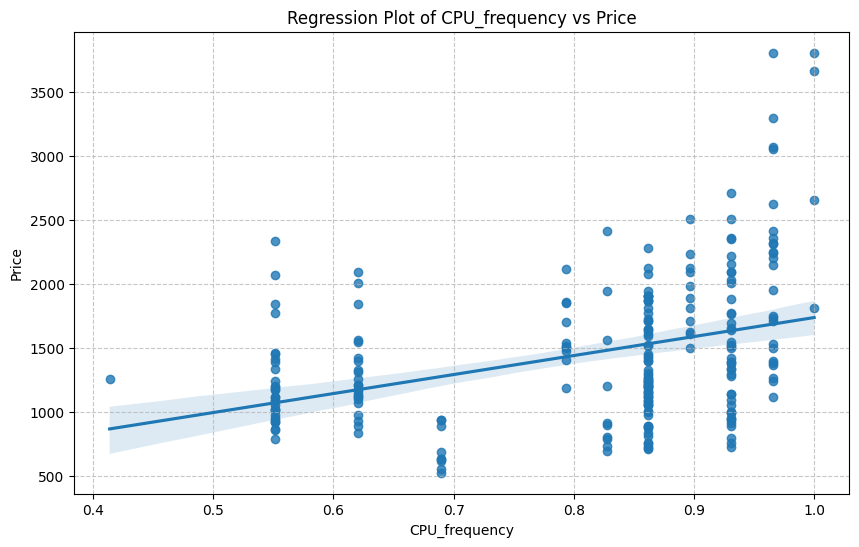

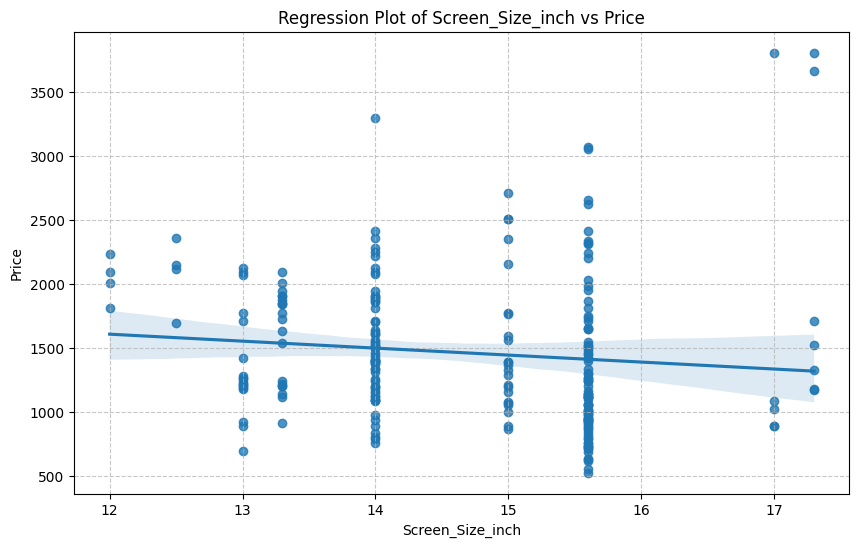

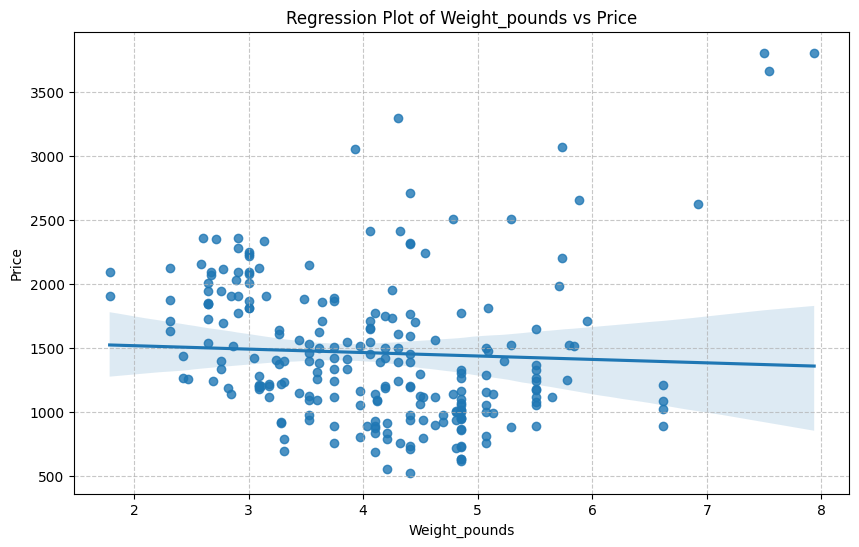


Generating Box Plots:


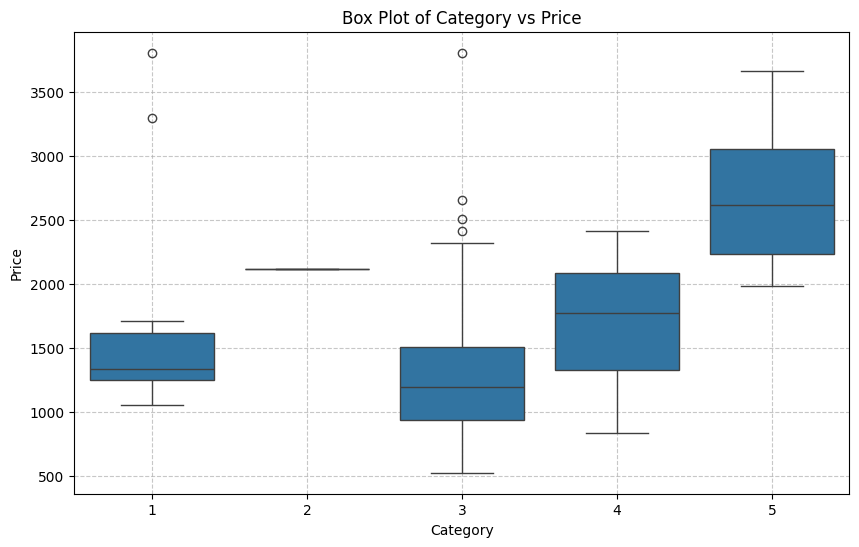

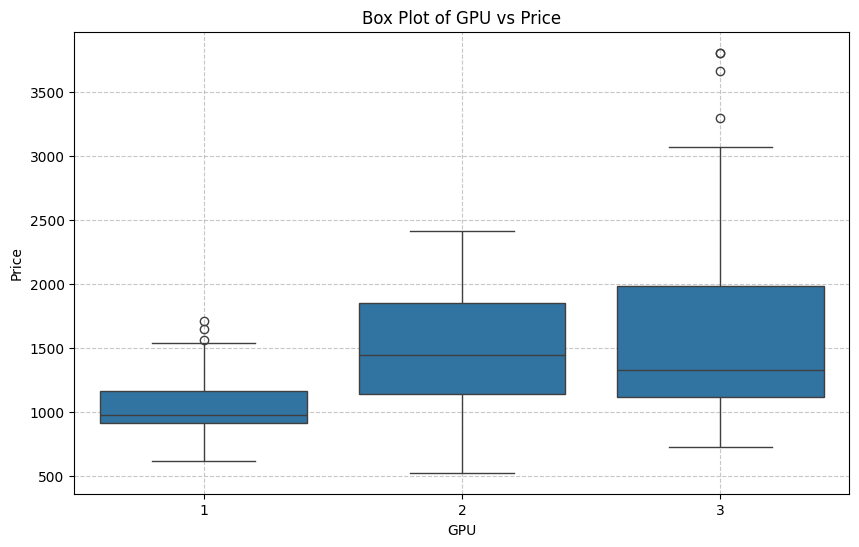

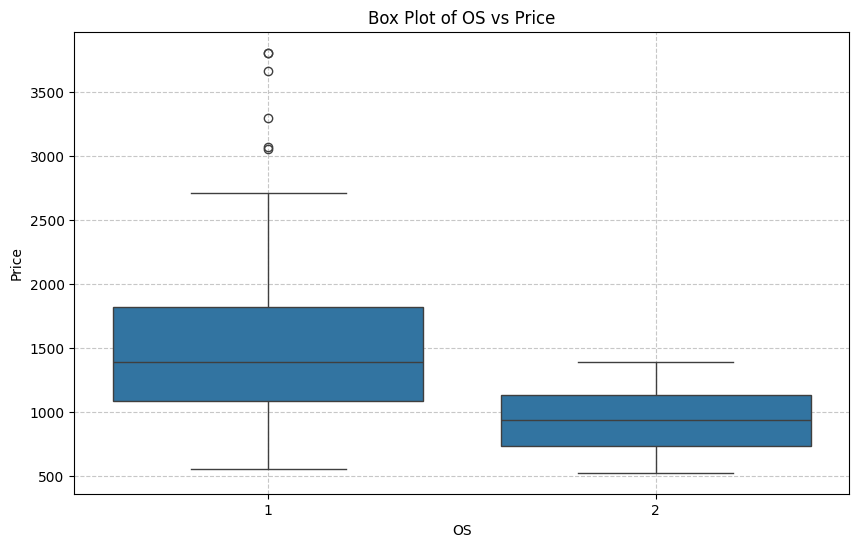

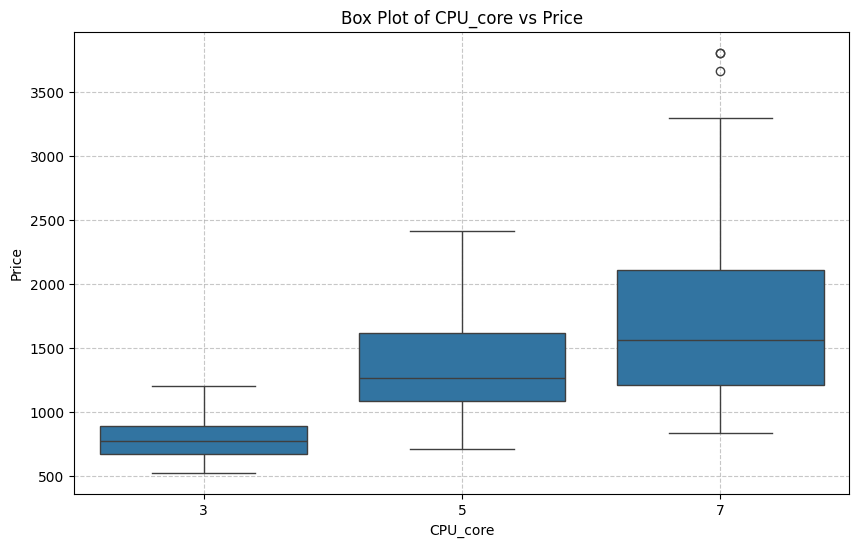

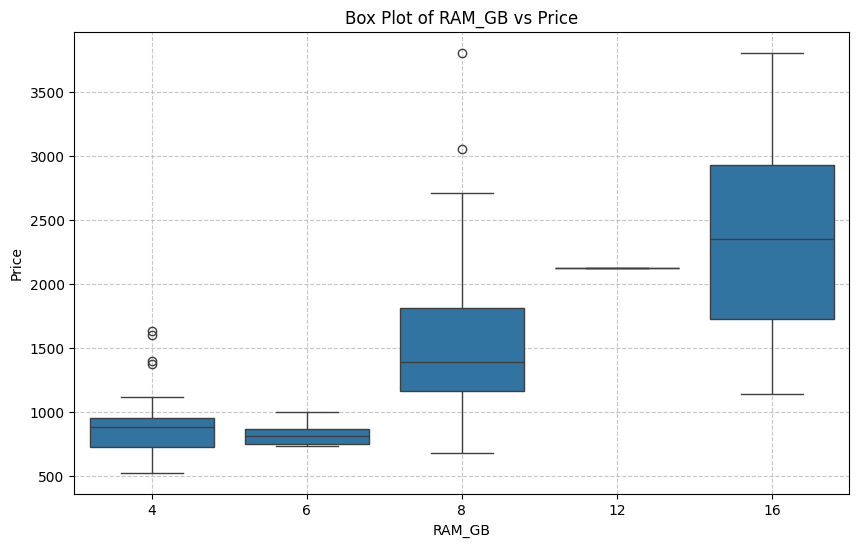

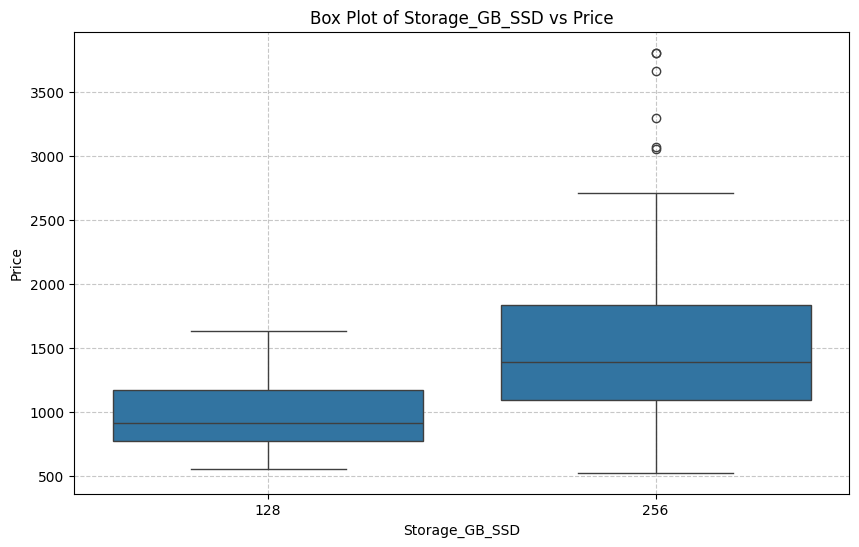

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create regression plots
regression_attributes = ["CPU_frequency", "Screen_Size_inch", "Weight_pounds"]

print("Generating Regression Plots:")
for attr in regression_attributes:
    plt.figure(figsize=(10, 6))
    sns.regplot(x=attr, y="Price", data=df)
    plt.title(f'Regression Plot of {attr} vs Price')
    plt.xlabel(attr)
    plt.ylabel('Price')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# 2. Create box plots
boxplot_attributes = ["Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"]

print("\nGenerating Box Plots:")
for attr in boxplot_attributes:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=attr, y="Price", data=df)
    plt.title(f'Box Plot of {attr} vs Price')
    plt.xlabel(attr)
    plt.ylabel('Price')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

Pivot Table of Mean Price by GPU and CPU_core:
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561


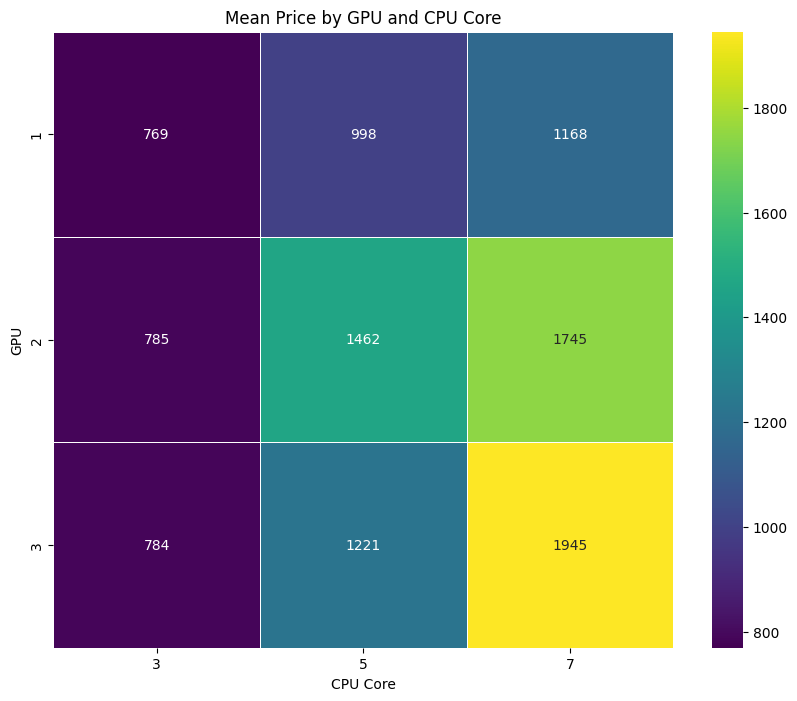

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Group the attributes "GPU", "CPU_core" and "Price"
#    The pivot table will implicitly group these.

# 2. Create a pivot table for this group, assuming the target variable to be 'Price' and aggregation function as mean
pivot_table_data = df.pivot_table(index='GPU', columns='CPU_core', values='Price', aggfunc='mean')

# Display the pivot table for inspection
print("Pivot Table of Mean Price by GPU and CPU_core:")
print(pivot_table_data)

# 3. Plot a pcolor plot for this pivot table.
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table_data, cmap='viridis', annot=True, fmt=".0f", linewidths=.5)
plt.title('Mean Price by GPU and CPU Core')
plt.xlabel('CPU Core')
plt.ylabel('GPU')
plt.show()